In [152]:
# Import necessayry libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.manifold import TSNE


In [153]:
# Load the dataset
data = pd.read_csv(r"D:\Sem_4\Unsupervised Machine Learning Lab (USLL)\Mall_Customers.csv")


In [154]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [155]:
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])


In [156]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


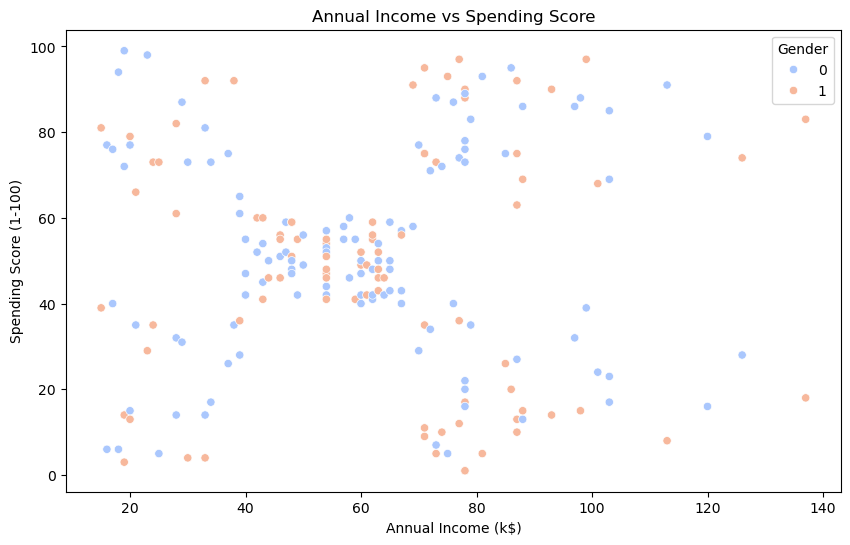

In [157]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=data, hue='Gender', palette='coolwarm')
plt.title('Annual Income vs Spending Score')
plt.show()

In [158]:
df = data.drop('CustomerID', axis=1)

In [159]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


<Figure size 1000x600 with 0 Axes>

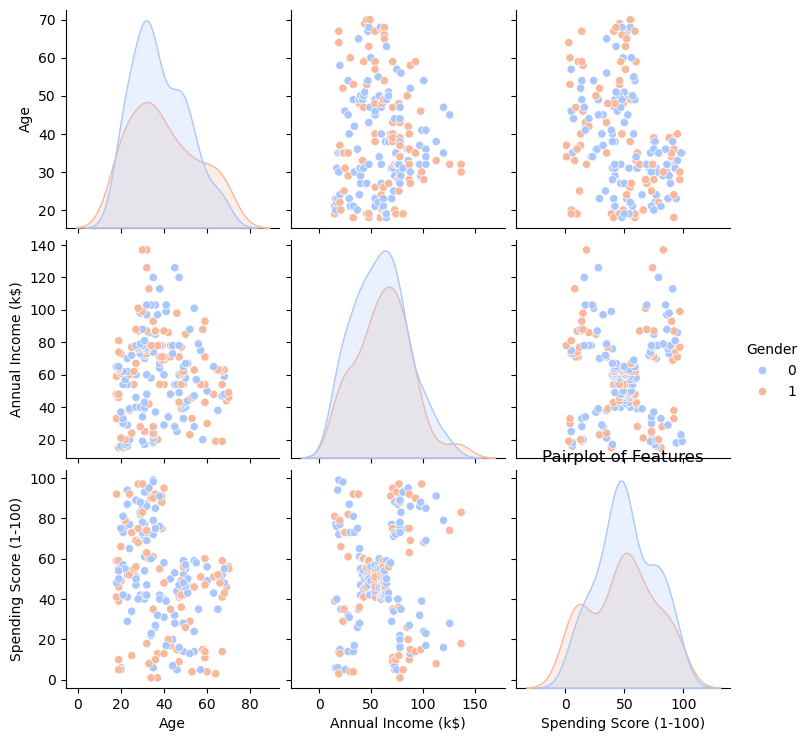

In [160]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='Gender', palette='coolwarm')
plt.title('Pairplot of Features')
plt.show()

In [161]:
X = df.drop('Gender', axis=1)
y = df['Gender']


In [162]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [163]:
# PCA Implementation
# Apply PCA to the standardized features
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance_pca = pca.explained_variance_ratio_
print("PCA (Principal Component Analysis):")
print(f"First component: {explained_variance_pca[0]*100:.2f}%")
print(f"Second component: {explained_variance_pca[1]*100:.2f}%")
print(f"Third component: {explained_variance_pca[2]*100:.2f}%")



PCA (Principal Component Analysis):
First component: 44.27%
Second component: 33.31%
Third component: 22.43%


In [164]:
# LDA Implementation
# Apply LDA to the standardized features
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y)
explained_variance_lda = lda.explained_variance_ratio_
print("LDA (Linear Discriminant Analysis):")
print(f"First component: {explained_variance_lda[0]*100:.2f}%")



LDA (Linear Discriminant Analysis):
First component: 100.00%


In [165]:
# SVD Implementation
# Apply Truncated SVD to the standardized features
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_scaled)

# Display the explained variance ratios for each method
explained_variance_svd = svd.explained_variance_ratio_
print("SVD (Singular Value Decomposition):")
print(f"First component: {explained_variance_svd[0]*100:.2f}%")
print(f"Second component: {explained_variance_svd[1]*100:.2f}%")




SVD (Singular Value Decomposition):
First component: 44.27%
Second component: 33.31%


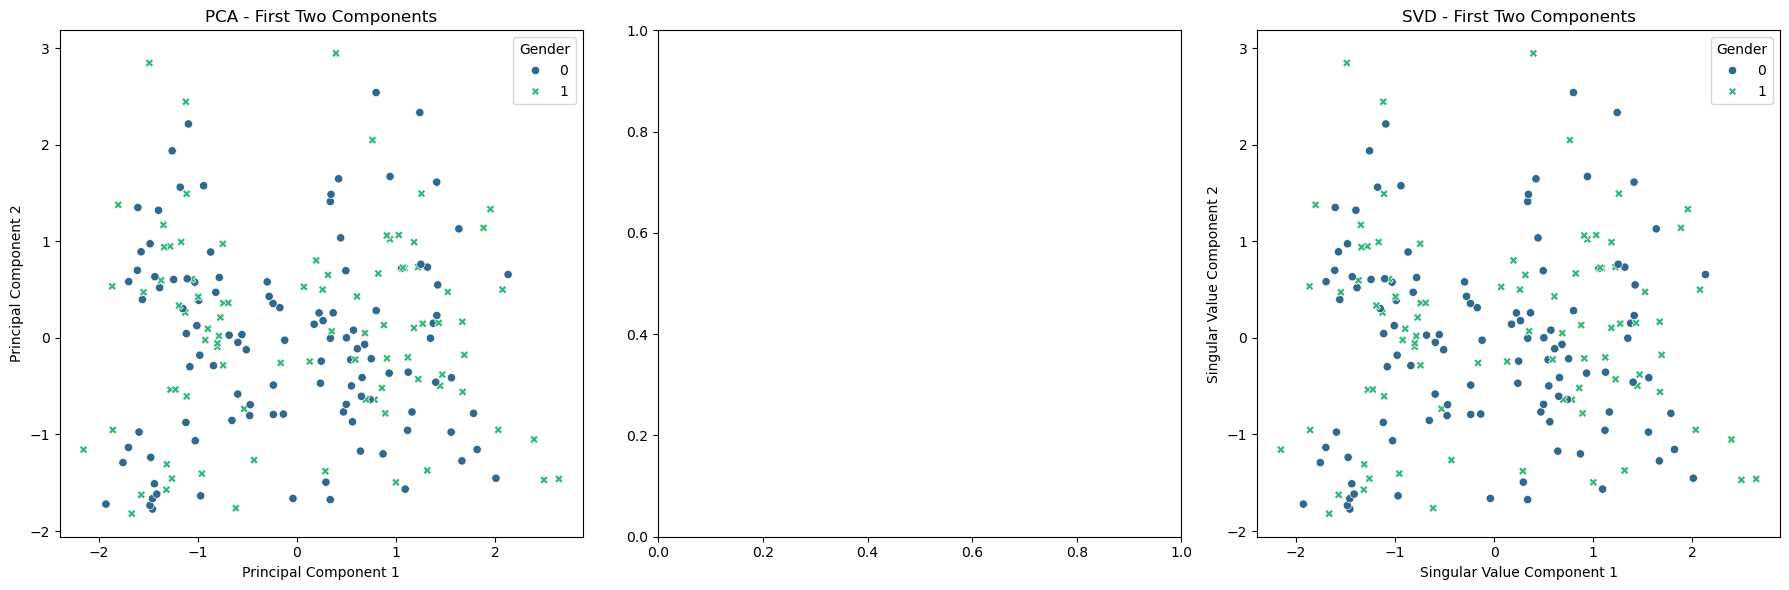

In [168]:
# Plotting the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# PCA Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, style=y, ax=ax[0], palette='viridis')
ax[0].set_title('PCA - First Two Components')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# LDA Plot
#sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, style=y, ax=ax[1], palette='viridis')
#ax[1].set_title('LDA Projection')
#ax[1].set_xlabel('LD 1')


# SVD Plot
sns.scatterplot(x=X_svd[:, 0], y=X_svd[:, 1], hue=y, style=y, ax=ax[2], palette='viridis')
ax[2].set_title('SVD - First Two Components')
ax[2].set_xlabel('Singular Value Component 1')
ax[2].set_ylabel('Singular Value Component 2')

plt.tight_layout()
plt.show()

C:\Users\Neil\AppData\Local\Temp\ipykernel_5428\2914951560.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='coolwarm')


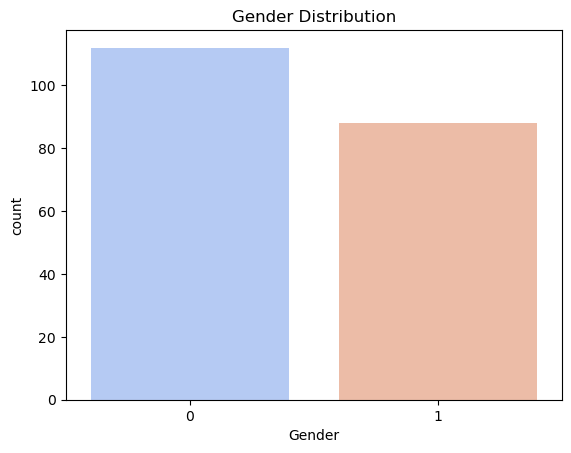

In [ ]:
sns.countplot(x='Gender', data=data, palette='coolwarm')
plt.title('Gender Distribution')
plt.show()

In [ ]:
# Use TSNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

c:\Users\Neil\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Neil\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Neil\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Neil\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Neil\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(

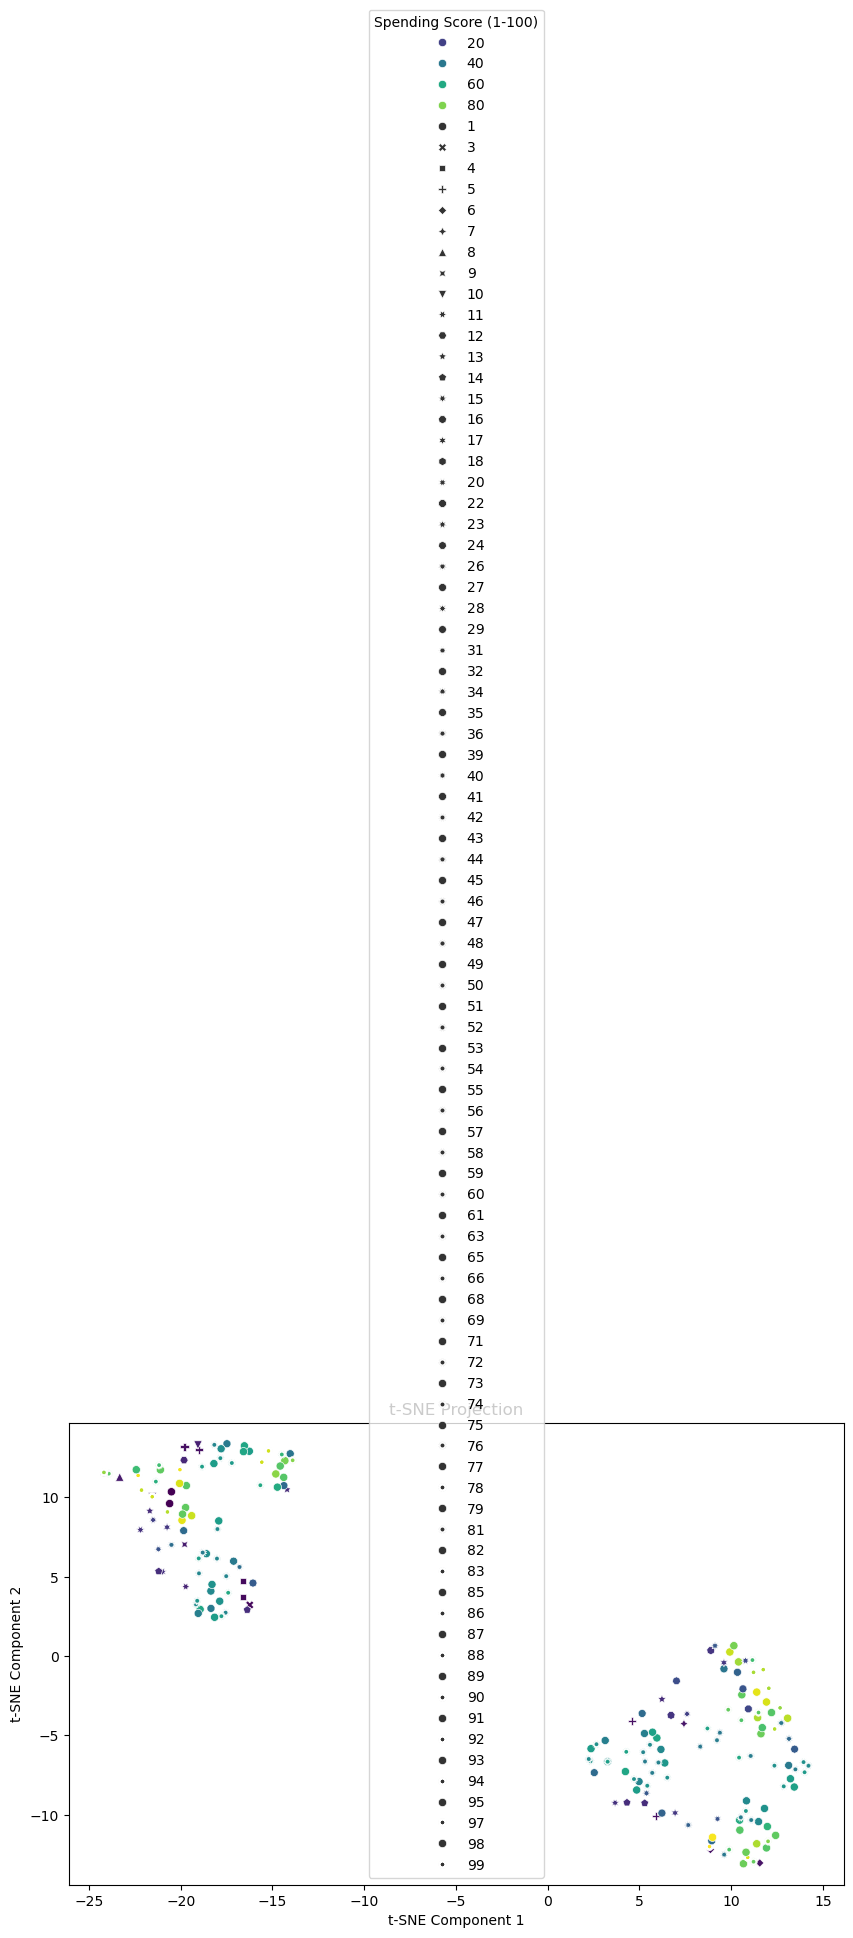

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, style=y, palette='viridis')
plt.title('t-SNE Projection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
# Using KMeans for clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)



c:\Users\Neil\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=5, random_state=42)

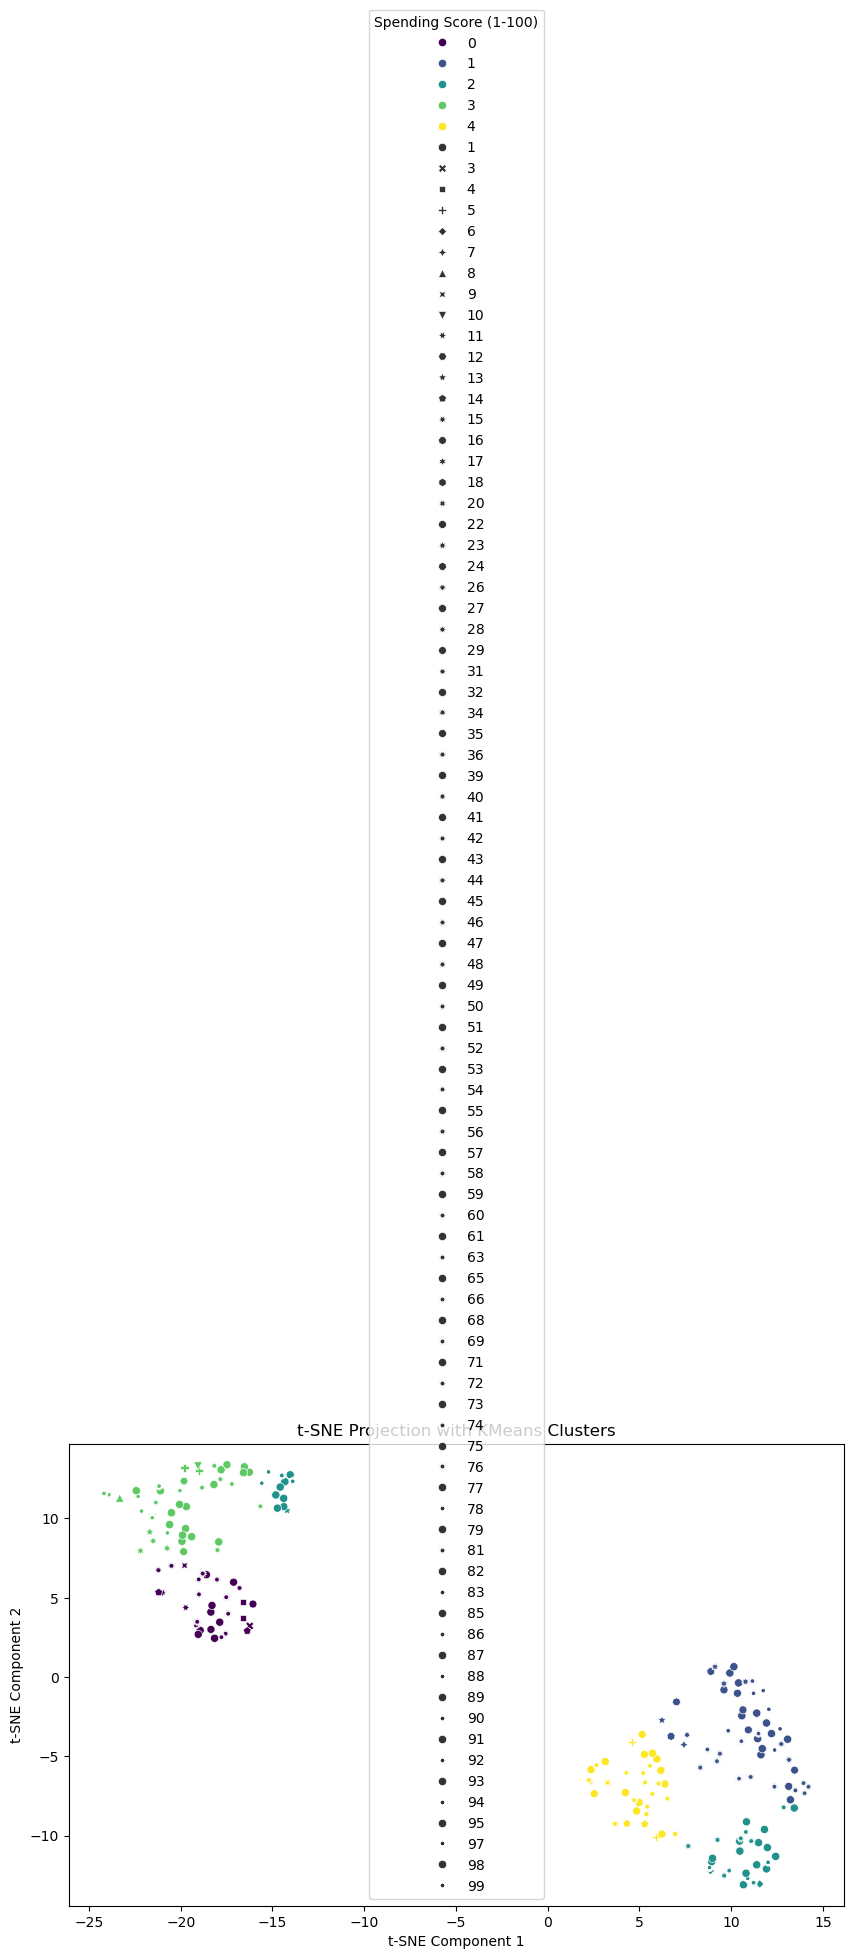

In [ ]:
# Visualizing the clusters of Kmeans